### What are Embedding?

Think of embedding as a way to translate words into a language that computer understand ---> number 

In [4]:
import numpy as np
import matplotlib.pyplot as plt


In [5]:
# Embedding models 
# 1) OpenAi - 1500 dimensions
# 2) HuggingFace - 768 dimensions



In [6]:
# Simplified 2D  example  (real embeddings  having hundereds of dimensions)

word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "Truck": [-0.45, 0.15]
}

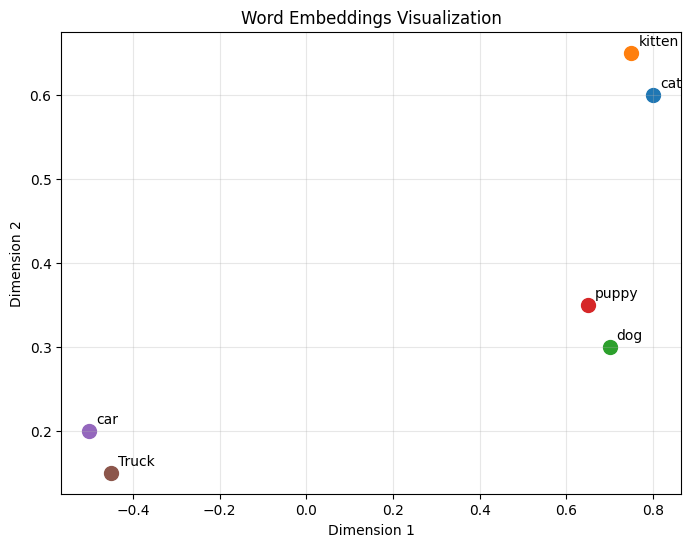

In [7]:
#plotting the embeddings

fig ,ax = plt.subplots(figsize=(8,6))
for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1],s=100)
    ax.annotate(word, (coords[0], coords[1]),
                xytext=(5,5), textcoords='offset points')
    
ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')
plt.title('Word Embeddings Visualization')
ax.grid(True,alpha=0.3)
plt.show()

### Measuring similarity between words using cosine similarity

In [8]:
def cosine_similarity(vec1, vec2):
    
    """
    Cosine Similarity measures the angle between two vectors.
    - Result close to 1 : very similar
    - Result close to 0 : not related
    - Result close to -1 : Opposite Meanings
    
    """
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    
    return dot_product / (norm_a * norm_b)

In [9]:
# Example usage
cat_vector = [0.8, 0.6,0.3]
kitten_vector = [0.75, 0.65,0.35]
car_vector = [-0.5, 0.2,0.1]
king_vector = [0.8,0.2,0.6]
queen_vector = [0.75,0.25,0.65]

cat_kitten_similarity = cosine_similarity(cat_vector, kitten_vector)
print(f"Cosine Similarity between 'cat' and 'kitten': {cat_kitten_similarity}")
cat_car_similarity = cosine_similarity(cat_vector, car_vector)
print(f"Cosine Similarity between 'cat' and 'car': {cat_car_similarity}")

king_queen_similarity = cosine_similarity(king_vector, queen_vector)
print(f"Cosine Similarity between 'king' and 'queen': {king_queen_similarity}")

Cosine Similarity between 'cat' and 'kitten': 0.9966186334192181
Cosine Similarity between 'cat' and 'car': -0.43718588548916804
Cosine Similarity between 'king' and 'queen': 0.996413616659966


### Create My First Embeddings

In [1]:
##  HuggingFace models

from langchain_huggingface import HuggingFaceEmbeddings



In [2]:
# Instantiating a simple Embeddings model (No API key required)

embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embedding


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

d:\RAG\RAG\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Abhinesh Singh\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [4]:
## create my first embedding
text ="Hello, I am learning about embeddings!"
embedding_vector = embedding.embed_query(text)
print(f"Text: {text}")
print(f"Length of the embedding vector: {len(embedding_vector)}")
print(embedding_vector) 

Text: Hello, I am learning about embeddings!
Length of the embedding vector: 384
[-0.01816326379776001, -0.09955169260501862, 0.013816027902066708, -0.00812597293406725, 0.01415228471159935, 0.0640648677945137, -0.006253377068787813, -0.003017888404428959, 0.025287209078669548, -0.02019863948225975, 0.02432972751557827, 0.07435064017772675, 0.05117722973227501, 0.02203851193189621, -0.05830617621541023, 0.01526821218430996, 0.023584362119436264, 0.09455390274524689, -0.06508845090866089, 0.013296646066009998, -0.020497558638453484, -0.05690857768058777, 0.03030332177877426, -0.08365609496831894, 0.026596298441290855, -0.015231452882289886, -0.04361540079116821, 0.05398401618003845, 0.09025716781616211, -0.08893883973360062, 0.03964461758732796, -0.008835024200379848, -0.03034374490380287, 0.07425564527511597, -0.0540991947054863, 0.11107997596263885, 0.036899879574775696, -0.008959847502410412, -0.06140241026878357, -0.0031433829572051764, 0.021958177909255028, 0.04220819100737572, -0.

In [7]:
sentence =[
    "I love machine learning.",
    "The cat is on the roof.",
    "The weather is nice today.",
    "I enjoy hiking in the mountains.",
    "The movie was fantastic!",
    "The book is very informative."
]

embeddings = embedding.embed_documents(sentence)
print(f" sentences: {sentence}")
print(f"Number of sentences: {len(sentence)}")
print(f"Length of each embedding vector: {len(embeddings)}")
print(embeddings)
print("\n")
print(embeddings[0])
print(embeddings[1])
print(embeddings[2])
print(embeddings[3])
print(embeddings[4])
print(embeddings[5])


 sentences: ['I love machine learning.', 'The cat is on the roof.', 'The weather is nice today.', 'I enjoy hiking in the mountains.', 'The movie was fantastic!', 'The book is very informative.']
Number of sentences: 6
Length of each embedding vector: 6
[[-0.01685112528502941, -0.07072174549102783, 0.08554110676050186, -0.001766124158166349, 0.04520879685878754, -0.05311212316155434, -0.04855525493621826, -0.031039126217365265, 0.019991979002952576, 0.001377831562422216, -0.05642637610435486, 0.08474870026111603, 0.03135889768600464, -0.009936279617249966, -0.025161895900964737, 0.0156457107514143, -0.050587594509124756, 0.010036714375019073, -0.09949712455272675, -0.11036434024572372, -0.054884880781173706, 0.0130549231544137, 0.0016936925239861012, 0.0010150388116016984, 0.028596192598342896, 0.01457247044891119, 0.020524272695183754, -0.008306245319545269, -0.01472774799913168, -0.05601470544934273, -0.012392638251185417, 0.05011460930109024, 0.0008125895983539522, 0.0393453128635883

In [8]:
from langchain_huggingface import HuggingFaceEmbeddings
import time

# Popular models comparison
models = {
    "all-MiniLM-L6-v2": {
        "size": 384,
        "description": "Fast and efficient, good quality",
        "use_case": "General purpose, real-time applications"
    },

    "all-mpnet-base-v2": {
        "size": 768,
        "description": "Best quality, slower than MiniLM",
        "use_case": "When quality matters more than speed"
    },

    "all-MiniLM-L12-v2": {
        "size": 384,
        "description": "Slightly better than L6, bit slower",
        "use_case": "Good balance of speed and quality"
    },

    "multi-qa-MiniLM-L6-cos-v1": {
        "size": 384,
        "description": "Optimized for question-answering",
        "use_case": "Q&A systems, semantic search"
    },

    "paraphrase-multilingual-MiniLM-L12-v2": {
        "size": 384,
        "description": "Supports 50+ languages",
        "use_case": "Multilingual applications"
    }
}

print("📚 Popular Open Source Embedding Models:\n")

for model_name, info in models.items():
    print(f"Model: sentence-transformers/{model_name}")
    print(f"📏 Embedding size: {info['size']} dimensions")
    print(f"📝 Description: {info['description']}")
    print(f"🎯 Use case: {info['use_case']}\n")

📚 Popular Open Source Embedding Models:

Model: sentence-transformers/all-MiniLM-L6-v2
📏 Embedding size: 384 dimensions
📝 Description: Fast and efficient, good quality
🎯 Use case: General purpose, real-time applications

Model: sentence-transformers/all-mpnet-base-v2
📏 Embedding size: 768 dimensions
📝 Description: Best quality, slower than MiniLM
🎯 Use case: When quality matters more than speed

Model: sentence-transformers/all-MiniLM-L12-v2
📏 Embedding size: 384 dimensions
📝 Description: Slightly better than L6, bit slower
🎯 Use case: Good balance of speed and quality

Model: sentence-transformers/multi-qa-MiniLM-L6-cos-v1
📏 Embedding size: 384 dimensions
📝 Description: Optimized for question-answering
🎯 Use case: Q&A systems, semantic search

Model: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
📏 Embedding size: 384 dimensions
📝 Description: Supports 50+ languages
🎯 Use case: Multilingual applications



### Cosine similarity  with HuggingFace embeddings

In [1]:
# Example sentences
sentences = [
    "The cat sat on the mat",
    "A feline rested on the rug",
    "The dog played in the yard",
    "I love programming in Python",
    "Python is my favorite programming language"
]


In [2]:
import numpy as np 
def cosine_similarity(vec1, vec2):
    
    """
    Cosine Similarity measures the angle between two vectors.
    - Result close to 1 : very similar
    - Result close to 0 : not related
    - Result close to -1 : Opposite Meanings
    
    """
    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    
    return dot_product / (norm_a * norm_b)

In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
embedding

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [4]:
embeddings = embedding.embed_documents(sentences)
embeddings


[[0.1304018348455429,
  -0.011870143935084343,
  -0.028117045760154724,
  0.05123864859342575,
  -0.055974461138248444,
  0.03019157610833645,
  0.0301612988114357,
  0.02469835989177227,
  -0.018370550125837326,
  0.058766789734363556,
  -0.02495318092405796,
  0.06015429645776749,
  0.039831750094890594,
  0.03323053941130638,
  -0.06131138652563095,
  -0.049373120069503784,
  -0.054863523691892624,
  -0.04007606953382492,
  0.05642912536859512,
  0.03915657103061676,
  -0.03473709896206856,
  -0.013247691094875336,
  0.031966231763362885,
  -0.06349925696849823,
  -0.06017860025167465,
  0.0782344862818718,
  -0.028303857892751694,
  -0.047442834824323654,
  0.040359266102313995,
  -0.006630869582295418,
  -0.06674093753099442,
  -0.004191359039396048,
  -0.02531164139509201,
  0.053341638296842575,
  0.017428111284971237,
  -0.09792359918355942,
  0.006061280146241188,
  -0.06524161994457245,
  0.04557257890701294,
  0.023641828447580338,
  0.0765848457813263,
  -0.0102643873542547

In [5]:
# Calculate cosine similarity between the all pairs of sentences
for i in range(len(sentences)):
    for j in range(i+1, len(sentences)):
        similarity = cosine_similarity(embeddings[i], embeddings[j])
        
        print(f"'{sentences[i]}' vs ' {sentences[j]}'")
        print(f"Cosine Similarity: {similarity:.3f}\n")
        

'The cat sat on the mat' vs ' A feline rested on the rug'
Cosine Similarity: 0.564

'The cat sat on the mat' vs ' The dog played in the yard'
Cosine Similarity: 0.188

'The cat sat on the mat' vs ' I love programming in Python'
Cosine Similarity: 0.020

'The cat sat on the mat' vs ' Python is my favorite programming language'
Cosine Similarity: 0.003

'A feline rested on the rug' vs ' The dog played in the yard'
Cosine Similarity: 0.275

'A feline rested on the rug' vs ' I love programming in Python'
Cosine Similarity: 0.065

'A feline rested on the rug' vs ' Python is my favorite programming language'
Cosine Similarity: 0.063

'The dog played in the yard' vs ' I love programming in Python'
Cosine Similarity: 0.122

'The dog played in the yard' vs ' Python is my favorite programming language'
Cosine Similarity: 0.098

'I love programming in Python' vs ' Python is my favorite programming language'
Cosine Similarity: 0.877



In [6]:
## Semantic Search Example - Retrieving the most relevant sentence for a query
# Test semantic search
documents = [
    "LangChain is a framework for developing applications powered by language models",
    "Python is a high-level programming language",
    "Machine learning is a subset of artificial intelligence",
    "Embeddings convert text into numerical vectors",
    "The weather today is sunny and warm"
]

query = "What is LangChain?"

In [12]:
def semantic_search(query,documents,embedding_model,top_k=2):
    """ Simple semantic search Implementation """
    
    # embed the query and documents
    query_embedding = embedding_model.embed_query(query) # covert the query into an embedding vector
    document_embeddings = embedding_model.embed_documents(documents) # embed the documents into embedding vectors
    
    
    ## Calculate  the similarity score 
    similarities = []
    
    for i, doc_emb in enumerate(document_embeddings):
        similarity = cosine_similarity(query_embedding, doc_emb)
        similarities.append((similarity, documents[i]))
        
    # Sort by Similarity
    similarities.sort(reverse=True)
    return similarities[:top_k]
    
        
    


In [13]:
results = semantic_search(query, documents, embedding)

In [14]:
results

[(np.float64(0.658697079732172),
  'LangChain is a framework for developing applications powered by language models'),
 (np.float64(0.1603702481115148),
  'Python is a high-level programming language')]

In [15]:
print(f"\n Semantic Search Results for: '{query}'")
for score, doc in results:
    print(f"Score: {score:.3f} | Document: {doc}")


 Semantic Search Results for: 'What is LangChain?'
Score: 0.659 | Document: LangChain is a framework for developing applications powered by language models
Score: 0.160 | Document: Python is a high-level programming language


In [17]:
query = "What is Embeddings?"
results = semantic_search(query, documents, embedding)
print(f"\n Semantic Search Results for: '{query}'")
for score, doc in results:
    print(f"Score: {score:.3f} | Document: {doc}")




 Semantic Search Results for: 'What is Embeddings?'
Score: 0.560 | Document: Embeddings convert text into numerical vectors
Score: 0.235 | Document: Machine learning is a subset of artificial intelligence


# Semantic Search Complete Flow

```text
                    User Query
                          │
                          │
                          ▼
              "What is LangChain?"
                          │
                          │
                          ▼
                 Embedding Model
            (Hugging Face Transformer)
                          │
                          │
                          ▼
                    Query Vector

              [0.22, 0.91, -0.44 ...]

──────────────────────────────────────────────

                     Documents
                          │
                          ▼

     Doc1 → "LangChain is framework..."
     Doc2 → "Python is programming..."
     Doc3 → "Machine Learning is AI..."
     Doc4 → "Embeddings convert text..."
                          │
                          │
                          ▼

                 Embedding Model
                          │
                          ▼

                  Document Vectors

     Doc1 → [0.11, 0.77, -0.21]
     Doc2 → [0.91, 0.15, 0.44]
     Doc3 → [0.05, 0.31, -0.88]
     Doc4 → [0.61, 0.22, -0.11]

──────────────────────────────────────────────

               Loop Through Documents

                    for loop start
                          │
                          ▼

            Query Vector  VS  Doc1 Vector
                          │
                          ▼
                Cosine Similarity
                          │
                          ▼
                       0.91

                          │
                          ▼

            Query Vector  VS  Doc2 Vector
                          │
                          ▼
                Cosine Similarity
                          │
                          ▼
                       0.33

                          │
                          ▼

            Query Vector  VS  Doc3 Vector
                          │
                          ▼
                Cosine Similarity
                          │
                          ▼
                       0.18

──────────────────────────────────────────────

                Store Similarity Scores

[
 (0.91, "LangChain is framework..."),
 (0.33, "Python is programming..."),
 (0.18, "Machine Learning is AI...")
]

──────────────────────────────────────────────

                     Sort Scores

                Highest → Lowest

Before Sort:

0.18
0.91
0.33

        │
        ▼

After Sort:

0.91
0.33
0.18

──────────────────────────────────────────────

                 Return Top Results

[
 (0.91, "LangChain is framework..."),
 (0.33, "Python is programming...")
]

──────────────────────────────────────────────

Final Output:
Most semantically similar documents
to the user query are returned.
```